In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

In [2]:
def count_lines_gz_safe(filename, csize = 1000):
    count = 0
    chunk_size = csize 
    try:
        with gzip.open(filename, 'rb') as f:
            leftover = b''
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                lines = (leftover + chunk).split(b'\n')
                leftover = lines.pop()  # dernière ligne peut être tronquée
                count += len(lines)
            if leftover:
                count += 1  # compte la dernière ligne même si tronquée
    except EOFError:
        # fichier tronqué, on arrête là et on retourne le compte
        pass
    return count

def process_parallel_load(foldernb, nb = [1,2,3,4,5,6,7,8,9], chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    # logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    # histo_s = np.zeros(len(logbins_s)-1)
    bins_s = np.arange(0, L**2)
    histo_s = np.zeros(len(bins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    for i in nb:
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                # histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
                histo_s += np.histogram(chunk.iloc[:, 0], bins = bins_s)[0]
                histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
                
                nblines += len(chunk)
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s= int(float(line.strip().split()[cols[0]]))

                    # id = np.searchsorted(logbins_s, s, side='right') -1
                    # histo_s[id] += 1
                    histo_s[s] +=1
                    
                    id = np.searchsorted(logbins_a, 1/s, side='left') - 1
                    histo_a[id] += 1
                    
                    if i >= limdata:
                        break
        
    logbins_s, loghisto_s = new_logbins(histo_s, nbins)
    
    # log_histo, log_bins = loghisto(histo_s)
    # norm_histo_s = loghisto_s/((np.diff(logbins_s)) * np.sum(loghisto_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    # return logbins_s, norm_histo_s, logbins_a, norm_histo_a
    return logbins_s, loghisto_s, logbins_a, norm_histo_a

def floor_sig(x, n=1): #Pour récupére le floor de la valeur
    p = int(np.floor(np.log10(abs(x))))
    fact = 10 ** (p - n + 1)
    return int(np.floor(x / fact) * fact)

def count_lines(Tfolder_nb, nbfolder):
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        min = 1e10
        print(nb)
        for i in range(1,nbfolder+1):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = count_lines_gz_safe(file)
            print (nbl)
            if nbl < min:
                min = nbl
        print(min)
        
def full_analysis(Tfolder_nb, nbins = 50, cols = [12], nbfolder = [1,2,3,4,5,6,7,8,9]): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in nbfolder:
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        print(min)
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a
    
def gamma_th():

    fnb = np.arange(1,15)
    folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
    """ folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
    Tvar = [read_parameters(folder)[2] for folder in folderpath]

    results = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)
    Thisto_s, Tbins_s, _, _, _ = zip(*results)

    Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
    Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
    _, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)
    
    gamma = (-Ttau_s) - (-Ttau_s[0]) - 1
    
    return Tvar, gamma, -Ttau_s
    

def log_exppowlaw(x, a, b, c):
    return np.log(a)-b*np.log(x)-x/c


#   On regarde l'évolution de la distance à la criticalité au cours du temps

In [20]:
nrows = 100000
data1 = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Memory_effects/Me82n9/random_random.gz", cols= [0,4,12], nrows = nrows)
sc_1 = data1[:,2]
s_1 = data1[:,1]
Nava_1 = data1[:,0]

data2 = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Memory_effects/Me83n9/random_random.gz", cols= [0,4,12], nrows = nrows)#skiprows = 26000
sc_2 = data2[:,2]
s_2 = data2[:,1]
Nava_2 = data2[:,0]

data3 = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Memory_effects/Me78n9/random_random.gz", cols= [0,4,12], nrows = nrows/10)#skiprows = 26000
sc_3 = data3[:,2]
s_3 = data3[:,1]
Nava_3 = data3[:,0]


data4 = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/Memory_effects/Me77n9/random_random.gz", cols= [0,4,12], nrows = nrows/100)
sc_4 = data4[:,2]
s_4 = data4[:,1]
Nava_4 = data4[:,0]


In [21]:
N = 128**2
mask1 = s_1 >= N/4
mask2 = s_2 >= N/4
mask3 = s_3 >= N/4
mask4 = s_4 >= N/4

In [22]:
w = 10
y_smooth1 = np.convolve(1/sc_1, np.ones(w)/w, mode='same')
y_smooth2 = np.convolve(1/sc_2, np.ones(w)/w, mode='same')
y_smooth3 = np.convolve(1/sc_3, np.ones(w)/w, mode='same')
y_smooth4 = np.convolve(1/sc_4, np.ones(w)/w, mode='same')

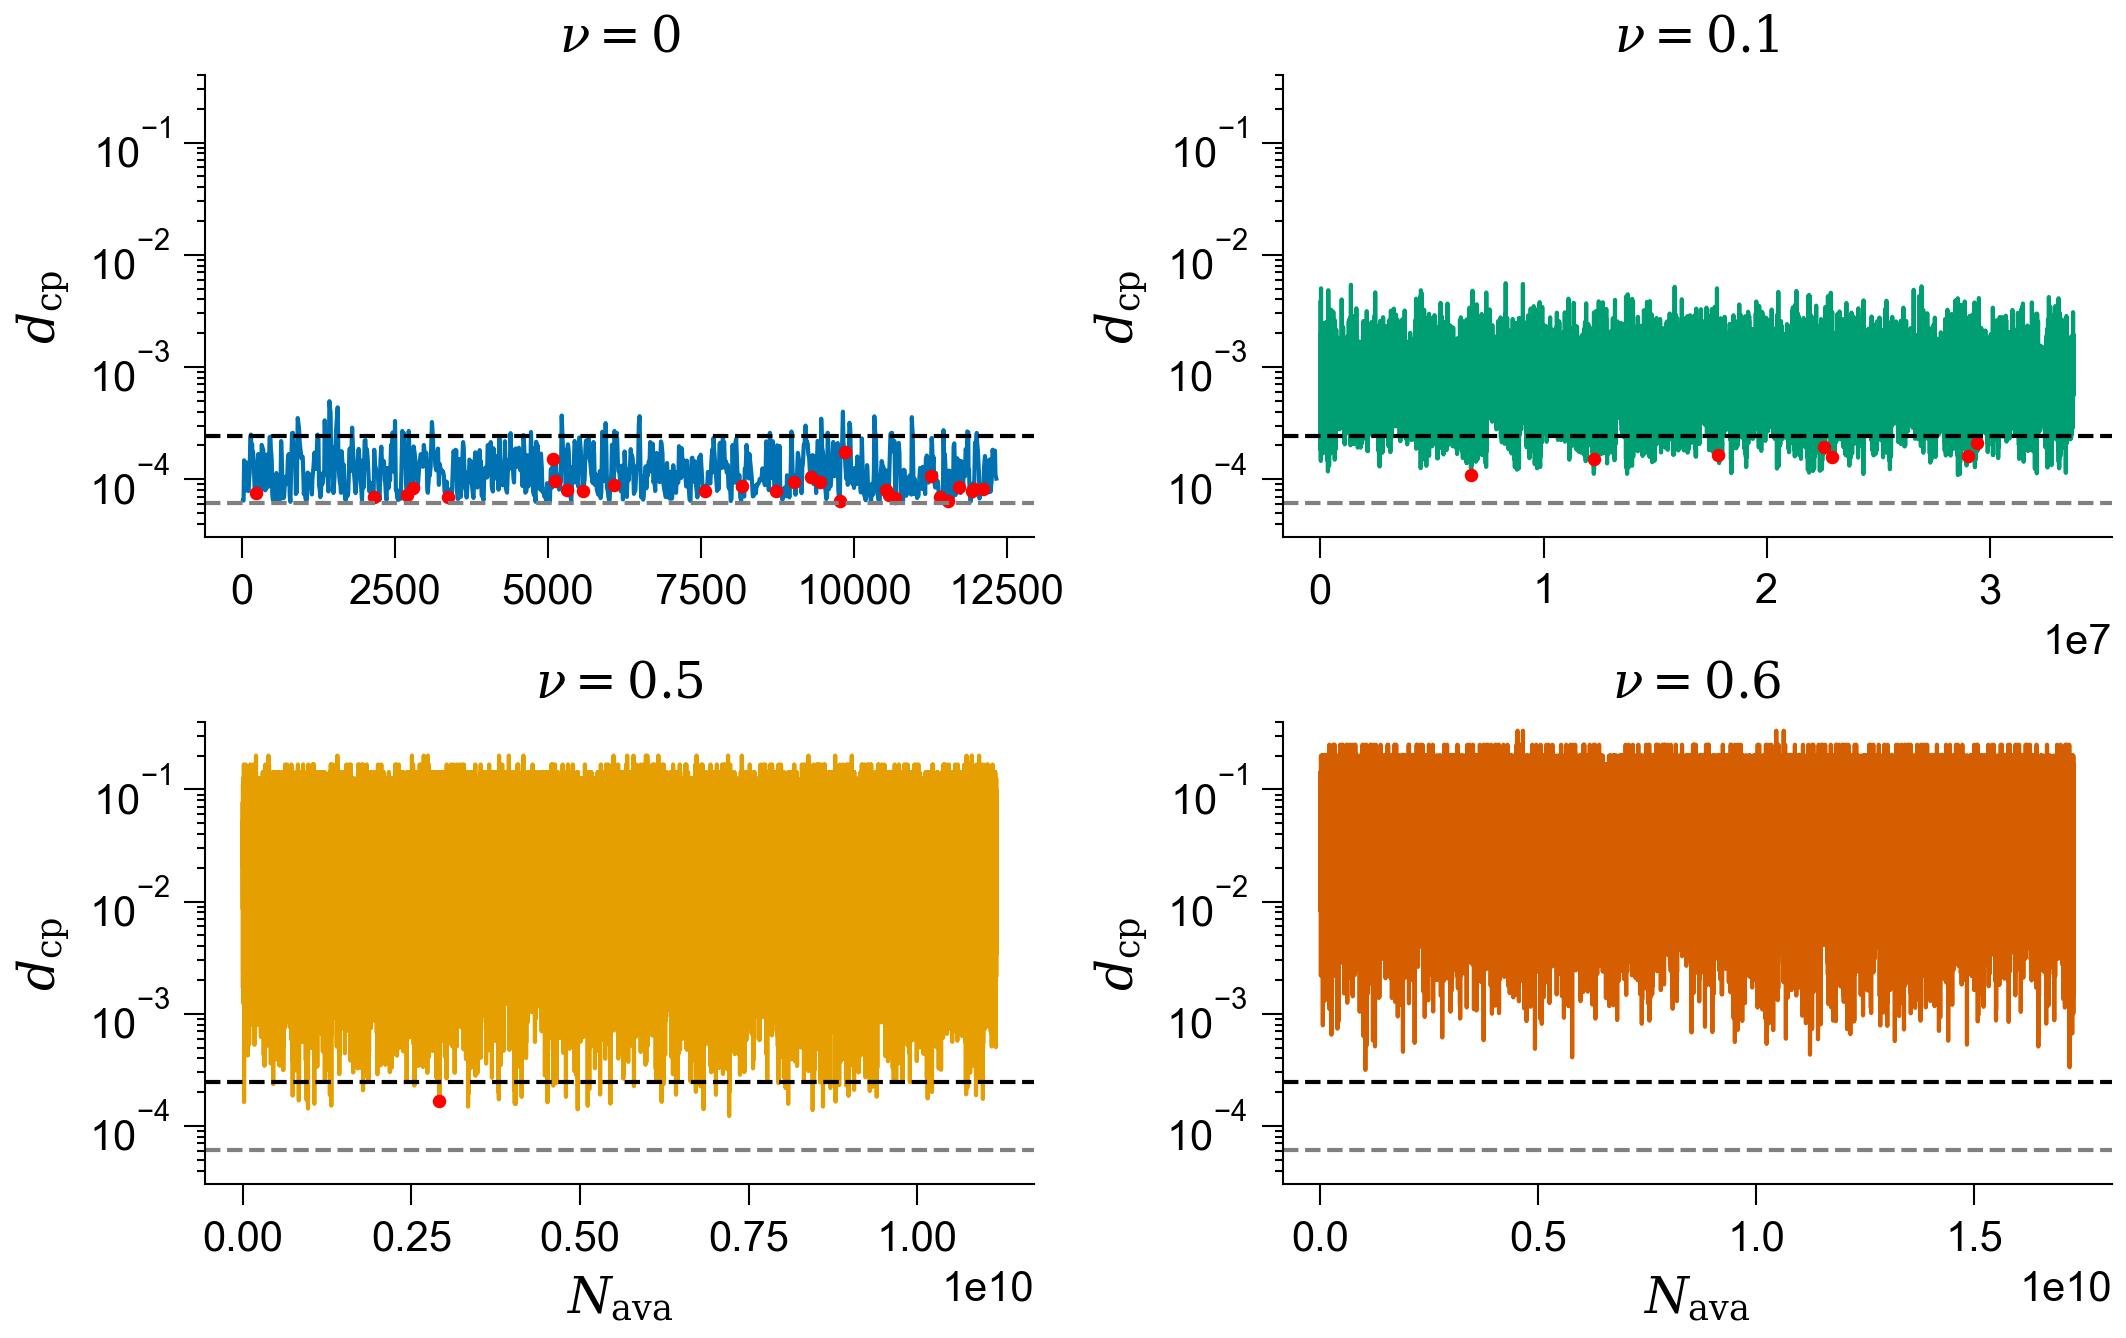

In [23]:
with plt.style.context(spstyle.get_style('thesis')):
    fig, ((ax, ax2),(ax3, ax4)) = plt.subplots(2,2,figsize = (8.2,4.8))
    fig.subplots_adjust(wspace = 0.3, hspace = 0.4)
    
    
    # mask3 = ((1/np.array(sc_diss) >= 1/2e3) &  (1/np.array(sc_diss) <= 1/40))
    leg4 = ax.plot(Nava_4, 1/sc_4, c = color_list[0], label = 0)
    ax.scatter(Nava_4[mask4], 1/sc_4[mask4], color = 'r', s = 5, zorder = 2)
    # ax.plot(Nava_4, y_smooth4, c = 'k', ls ='-')
    
    leg3 = ax2.plot(Nava_3, 1/sc_3, c = color_list[1], label = 0.5)
    ax2.scatter(Nava_3[mask3], 1/sc_3[mask3], color = 'r', s = 5, zorder = 2)
    # ax2.plot(Nava_3, y_smooth3, c = 'k', ls ='-')
    
    leg2 = ax3.plot(Nava_2, 1/sc_2, c = color_list[2], label = 0.5)
    ax3.scatter(Nava_2[mask2], 1/sc_2[mask2], color = 'r', s = 5, zorder = 2)
    # ax3.plot(Nava_2, y_smooth2, c = 'k', ls ='-')
    
    leg1 = ax4.plot(Nava_1, 1/sc_1, c = color_list[3], label = 0.5)
    ax4.scatter(Nava_1[mask1], 1/sc_1[mask1], color = 'r', s = 5, zorder = 2)
    # ax4.plot(Nava_1, y_smooth1, c = 'k', ls ='-')
    
    ax.axhline(4/N, ls = '--', c = 'k')
    ax.axhline(1/N, ls = '--', c = 'gray')
    # ax.set_xlabel(r"$N_{\mathrm{ava}}$")
    ax.set_ylabel(r"$d_\mathrm{cp}$")
    ax.set_yscale("log")
    ax.set_ylim(1/(2*128*128), 0.4)
    ax.set_title(r"$\nu = 0$")
    
    ax2.axhline(4/N, ls = '--', c = 'k')
    ax2.axhline(1/N, ls = '--', c = 'gray')
    # ax2.set_xlabel(r"$N_{\mathrm{ava}}$")
    ax2.set_ylabel(r"$d_\mathrm{cp}$")
    ax2.set_yscale("log")
    ax2.set_ylim(1/(2*128*128), 0.4)
    ax2.set_title(r"$\nu = 0.1$")
    
    ax3.axhline(4/N, ls = '--', c = 'k')
    ax3.axhline(1/N, ls = '--', c = 'gray')
    ax3.set_xlabel(r"$N_{\mathrm{ava}}$")
    ax3.set_ylabel(r"$d_\mathrm{cp}$")
    ax3.set_yscale("log")
    ax3.set_ylim(1/(2*128*128), 0.4)
    ax3.set_title(r"$\nu = 0.5$")
    
    ax4.axhline(4/N, ls = '--', c = 'k')
    ax4.axhline(1/N, ls = '--', c = 'gray')
    ax4.set_xlabel(r"$N_{\mathrm{ava}}$")
    ax4.set_ylabel(r"$d_\mathrm{cp}$")
    ax4.set_yscale("log")
    ax4.set_ylim(1/(2*128*128), 0.4)
    ax4.set_title(r"$\nu = 0.6$")
    
    
    # plt.savefig("s_c(t).pdf", dpi = 300)
    plt.show()

# s*|x

In [3]:
Tfolder = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp{}n".format(i) for i in [19,20,21]] 
foldernb = np.arange(1,10)
Tnbline = [None]*len(Tfolder)
Tnu = [None]*len(Tfolder)
TL = [None]*len(Tfolder)

f_log_histo = []
f_bin_centers_s = []
f_bin_centers_a = []
f_norm_histo_a = []


for j, folder in enumerate(Tfolder):
    Tnu[j] = read_parameters("{}1".format(folder))[2]
    TL[j] = read_parameters("{}1".format(folder))[0]
    
    min = 1e10
    for n in foldernb:
        file = "{}{}/random_random.gz".format(folder, n)
        nbl = floor_sig(count_lines_gz_safe(file), 2)
        if nbl < min:
            min = nbl
    Tnbline[j] = min
    print(min)

6300
6300
5800


[  0.           2.01587302   4.03174603   6.04761905   8.06349206
  10.07936508  12.0952381   14.11111111  16.12698413  18.14285714
  20.15873016  22.17460317  24.19047619  26.20634921  28.22222222
  30.23809524  32.25396825  34.26984127  36.28571429  38.3015873
  40.31746032  42.33333333  44.34920635  46.36507937  48.38095238
  50.3968254   52.41269841  54.42857143  56.44444444  58.46031746
  60.47619048  62.49206349  64.50793651  66.52380952  68.53968254
  70.55555556  72.57142857  74.58730159  76.6031746   78.61904762
  80.63492063  82.65079365  84.66666667  86.68253968  88.6984127
  90.71428571  92.73015873  94.74603175  96.76190476  98.77777778
 100.79365079 102.80952381 104.82539683 106.84126984 108.85714286
 110.87301587 112.88888889 114.9047619  116.92063492 118.93650794
 120.95238095 122.96825397 124.98412698 127.        ]


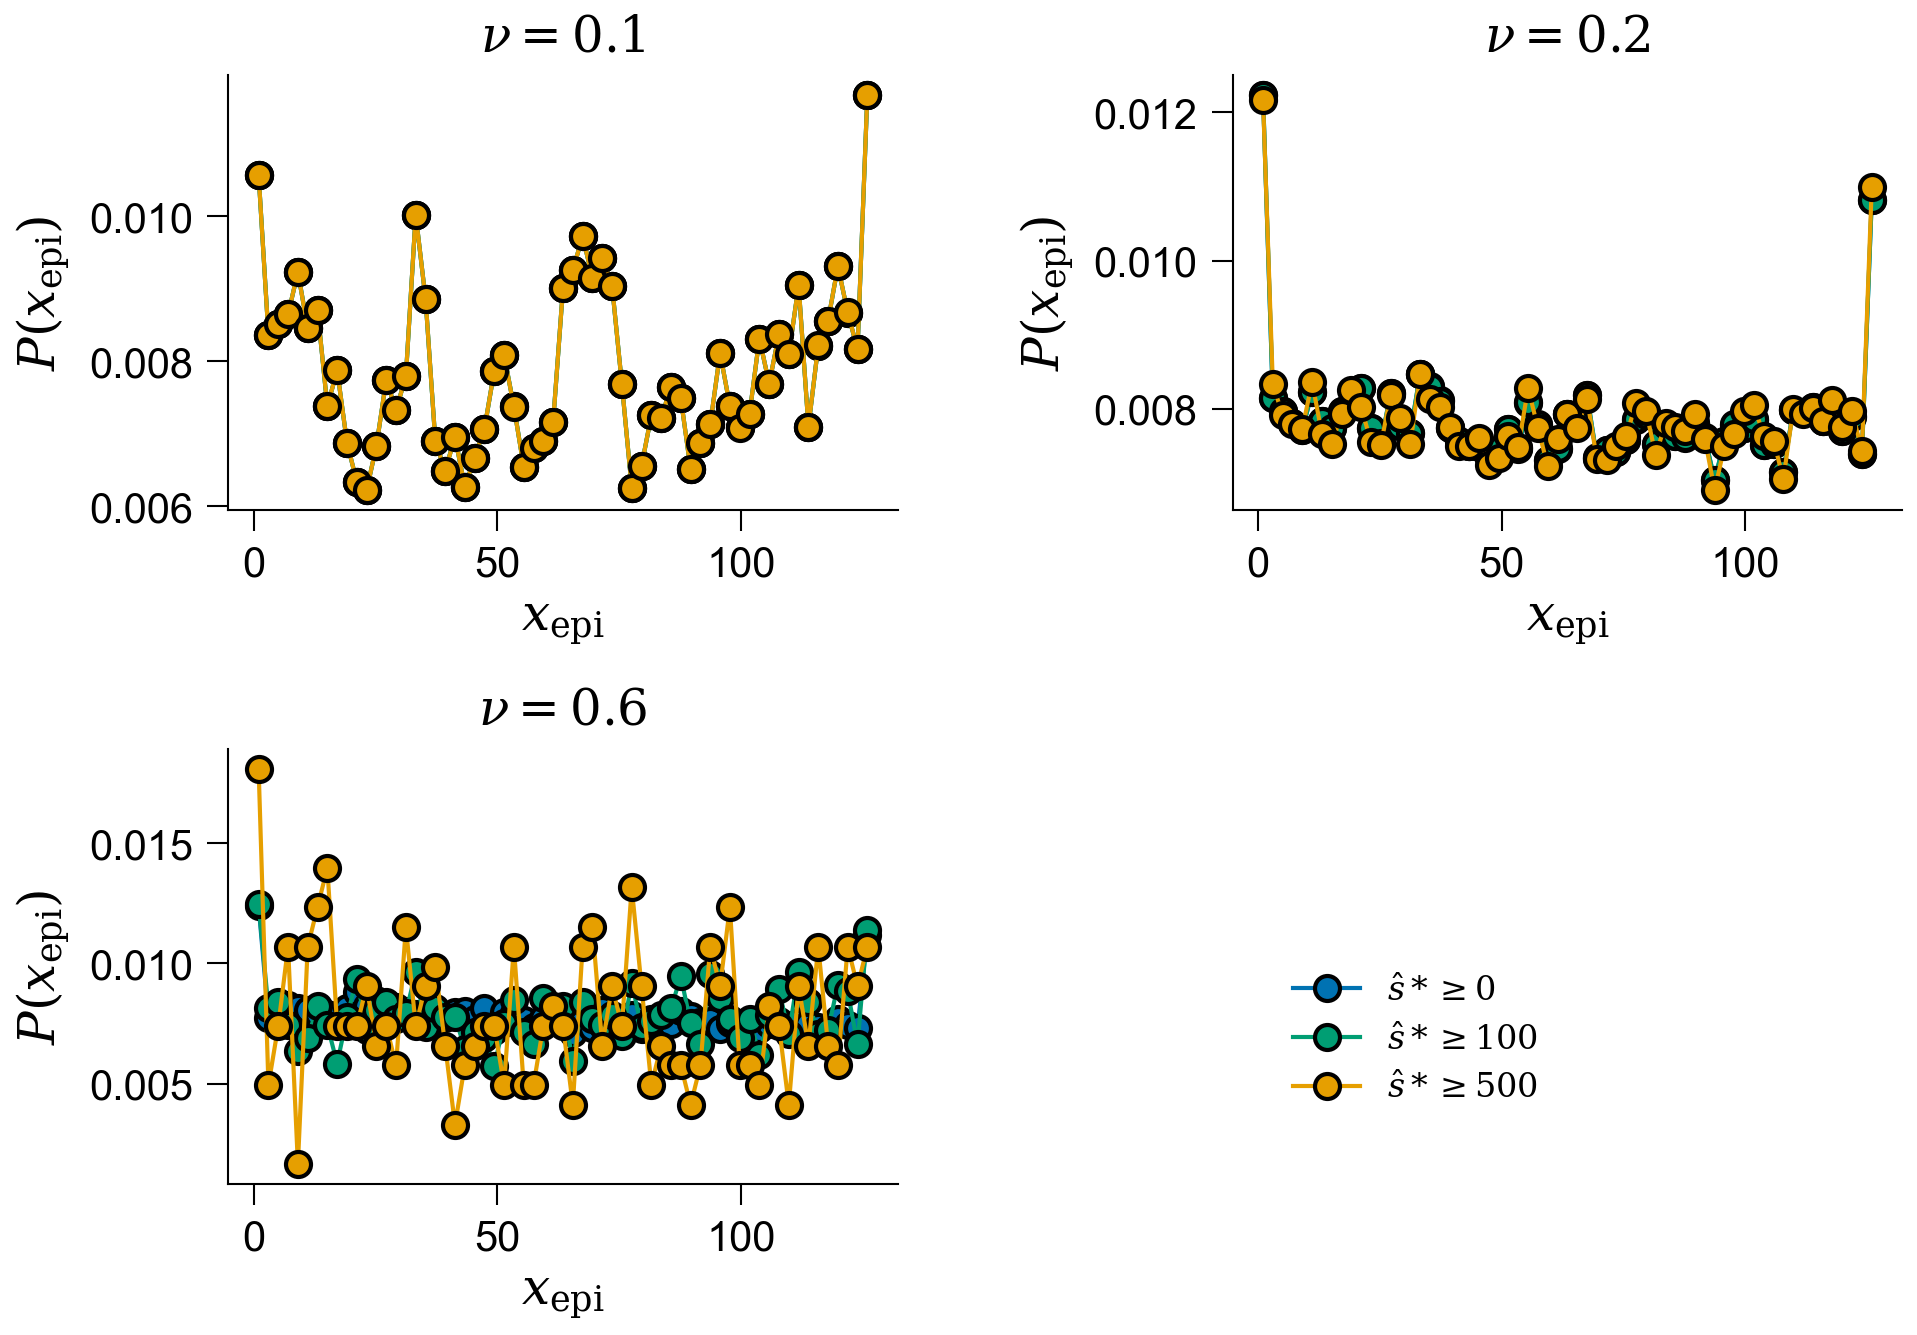

In [54]:
cols = [4,8,10]
Tnu = [0.1,0.2,0.6]
L1 = 128
L2 = 512
N = L1 * L2
bins = np.linspace(0,127,64)
print(bins)
bins_center = (bins[:-1] + bins[1:])/2
histo_xepi = []
histo_xcom = []

Tsmin = [0,100, 500]
Tsmin_leg = ["0", "100", "500"]
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(2,2,figsize = (7.2, 4.8))
    fig.subplots_adjust(wspace = 0.5, hspace = 0.55)
    ax = ax.flatten()
    
    for j, folder in enumerate(Tfolder):
        data = np.empty((0, 13))
        for i, n in enumerate(foldernb):
            file = "{}{}/random_random.gz".format(folder, n)
            with gzip.open(file, "rt") as f:
                skip_first_line = f.readline()
                lines = [next(f) for _ in range(Tnbline[j])]

            data = np.vstack((data, np.array([line.split() for line in lines])))
            
        f_data = data[:,cols].astype(int)
        for k, smin in enumerate(Tsmin):
            mask = f_data[:,1] >= smin
            f2_data = f_data[mask]
            x, y = np.unravel_index(f2_data[:,2], (L1,L2))
            # print(x.max(), y.max())
            histo_xepi = np.histogram(x, bins = bins, density = True)[0]
            
            ax[j].plot(bins_center, histo_xepi, label = r"$\hat s* \geq {}$".format(Tsmin_leg[k]), c = color_list[k], marker = 'o')
            ax[j].set_title(r"$\nu = {}$".format(Tnu[j]))
            ax[j].set_xlabel(r"$x_\mathrm{epi}$")
            ax[j].set_ylabel(r"$P(x_\mathrm{epi})$")
            # ax[j].set_yscale('log')
            
    ax[0].legend(bbox_to_anchor = (2,-1))
    ax[3].set_axis_off()
    plt.show()   


/home/kduplat/Documents/py38/lib/python3.8/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


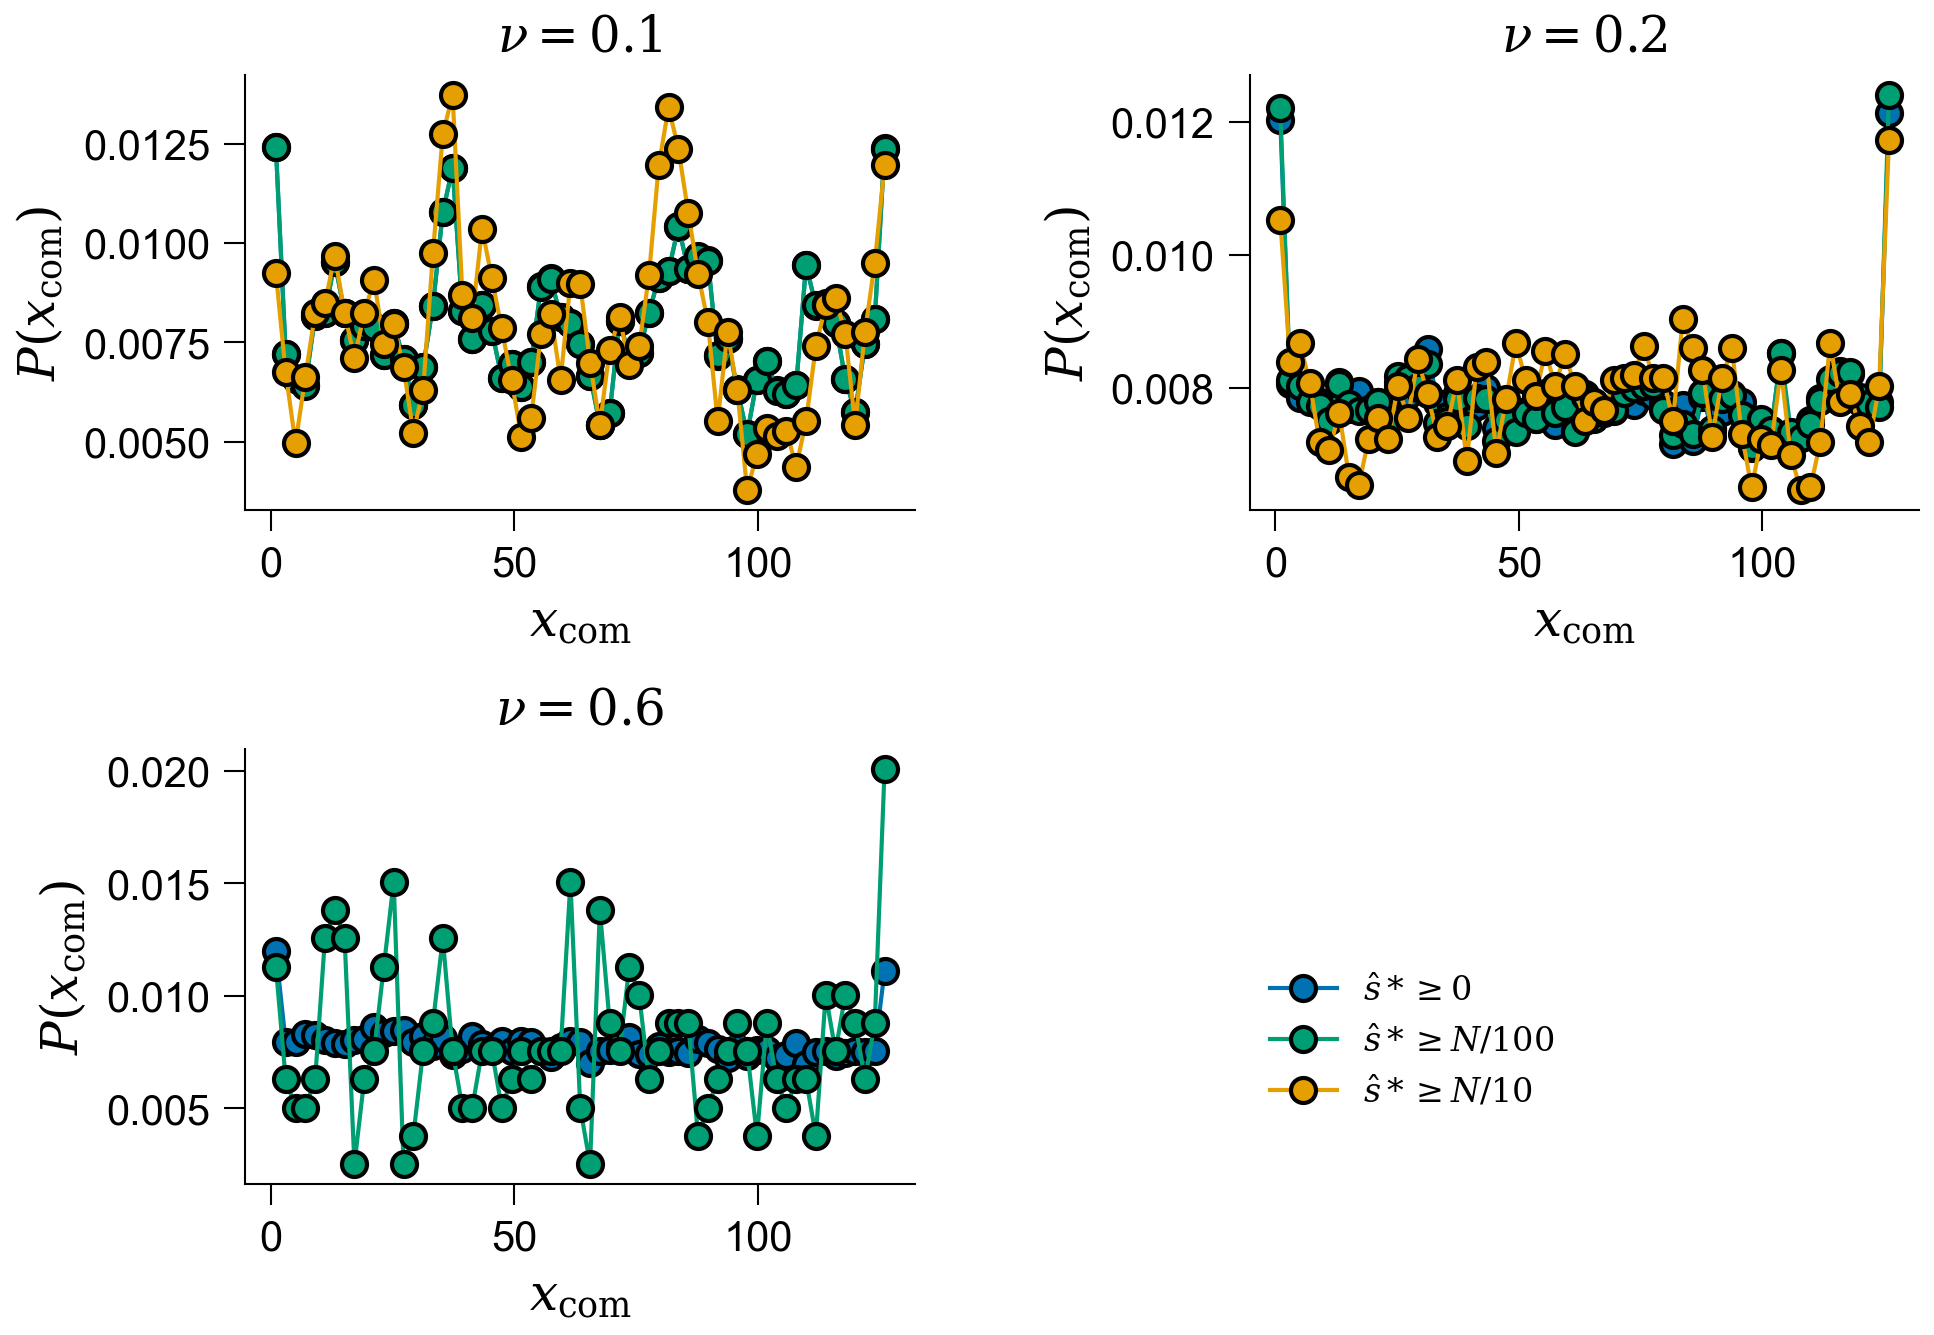

In [57]:
cols = [4,8,11]
Tnu = [0.1,0.2,0.6]
L1 = 128
L2 = 512
bins = np.linspace(0,127,64)
bins_center = (bins[:-1] + bins[1:])/2
histo_xepi = []
histo_xcom = []
Tsmin = [0,N/100, N/10]
Tsmin_leg = ["0", "N/100", "N/10"]
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(2,2,figsize = (7.2, 4.8))
    fig.subplots_adjust(wspace = 0.5, hspace = 0.55)
    ax = ax.flatten()
    
    for j, folder in enumerate(Tfolder):
        data = np.empty((0, 13))
        for i, n in enumerate(foldernb):
            file = "{}{}/random_random.gz".format(folder, n)
            with gzip.open(file, "rt") as f:
                skip_first_line = f.readline()
                lines = [next(f) for _ in range(Tnbline[j])]

            data = np.vstack((data, np.array([line.split() for line in lines])))
            
        f_data = data[:,cols].astype(int)
        for k, smin in enumerate(Tsmin):
            mask = f_data[:,1] >= smin
            f2_data = f_data[mask]
            x, y = np.unravel_index(f2_data[:,2], (L1,L2))
            histo_xepi = np.histogram(x, bins = bins, density = True)[0]
            
            ax[j].plot(bins_center, histo_xepi, label = r"$\hat s* \geq {}$".format(Tsmin_leg[k]), c = color_list[k], marker = 'o')
            ax[j].set_title(r"$\nu = {}$".format(Tnu[j]))
            ax[j].set_xlabel(r"$x_\mathrm{com}$")
            ax[j].set_ylabel(r"$P(x_\mathrm{com})$")
            # ax[j].set_yscale('log')
            
    ax[0].legend(bbox_to_anchor = (2,-1))
    ax[3].set_axis_off()
    plt.show()   
